# SciFact Dataset Quick EDA

Короткая разведка датасета `BEIR SciFact`: размеры, структура, базовые длины текстов и простые распределения по разметке `qrels`.

Если в kernel ещё нет зависимостей, достаточно выполнить:

```python
%pip install pandas matplotlib
```


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path.cwd() / "notebooks"

DATASET_DIR = NOTEBOOK_DIR / "data" / "scifact"
QRELS_PATH = DATASET_DIR / "qrels" / "test.tsv"

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory was not found: {DATASET_DIR}. Run the demo notebook download step first."
    )


In [2]:
def load_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file]

corpus = pd.DataFrame(load_jsonl(DATASET_DIR / "corpus.jsonl"))
queries = pd.DataFrame(load_jsonl(DATASET_DIR / "queries.jsonl"))
qrels = pd.read_csv(QRELS_PATH, sep="\t").rename(
    columns={
        "query-id": "query_id",
        "corpus-id": "corpus_id",
        "score": "relevance",
    }
)

corpus["title_words"] = corpus["title"].fillna("").str.split().str.len()
corpus["text_words"] = corpus["text"].fillna("").str.split().str.len()
queries["query_words"] = queries["text"].fillna("").str.split().str.len()
qrels_per_query = qrels.groupby("query_id").size().rename("relevant_docs")

corpus.head(3)


,_id,title,text,metadata,title_words,text_words
0,4983,Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic res...,Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical developme...,{},17,278
1,5836,Induction of myelodysplasia by myeloid-derived suppressor cells.,Myelodysplastic syndromes (MDS) are age-dependent stem cell malignancies that share biological features of activated...,{},7,201
2,7912,"BC1 RNA, the transcript from a master gene for ID element amplification, is able to prime its own reverse transcript...","ID elements are short interspersed elements (SINEs) found in high copy number in many rodent genomes. BC1 RNA, an ID...",{},20,180


In [3]:
overview = pd.DataFrame(
    {
        "metric": [
            "documents_in_corpus",
            "queries_total",
            "queries_with_qrels",
            "qrels_rows",
            "empty_titles",
            "empty_texts",
        ],
        "value": [
            len(corpus),
            len(queries),
            qrels["query_id"].nunique(),
            len(qrels),
            int(corpus["title"].fillna("").str.strip().eq("").sum()),
            int(corpus["text"].fillna("").str.strip().eq("").sum()),
        ],
    }
)

length_summary = pd.DataFrame(
    {
        "object": ["document_title", "document_text", "query_text", "relevant_docs_per_query"],
        "mean": [
            corpus["title_words"].mean(),
            corpus["text_words"].mean(),
            queries["query_words"].mean(),
            qrels_per_query.mean(),
        ],
        "median": [
            corpus["title_words"].median(),
            corpus["text_words"].median(),
            queries["query_words"].median(),
            qrels_per_query.median(),
        ],
        "p90": [
            corpus["title_words"].quantile(0.9),
            corpus["text_words"].quantile(0.9),
            queries["query_words"].quantile(0.9),
            qrels_per_query.quantile(0.9),
        ],
        "max": [
            corpus["title_words"].max(),
            corpus["text_words"].max(),
            queries["query_words"].max(),
            qrels_per_query.max(),
        ],
    }
).round(2)

qrels_distribution = (
    qrels["relevance"].value_counts().sort_index().rename_axis("relevance").reset_index(name="count")
)

display(overview)
display(length_summary)
display(qrels_distribution)


,metric,value
0,documents_in_corpus,5183
1,queries_total,1109
2,queries_with_qrels,300
3,qrels_rows,339
4,empty_titles,0
5,empty_texts,0


,object,mean,median,p90,max
0,document_title,12.82,12.0,19.0,40
1,document_text,201.81,192.0,295.0,1524
2,query_text,12.38,12.0,19.0,39
3,relevant_docs_per_query,1.13,1.0,1.0,5


,relevance,count
0,1,339


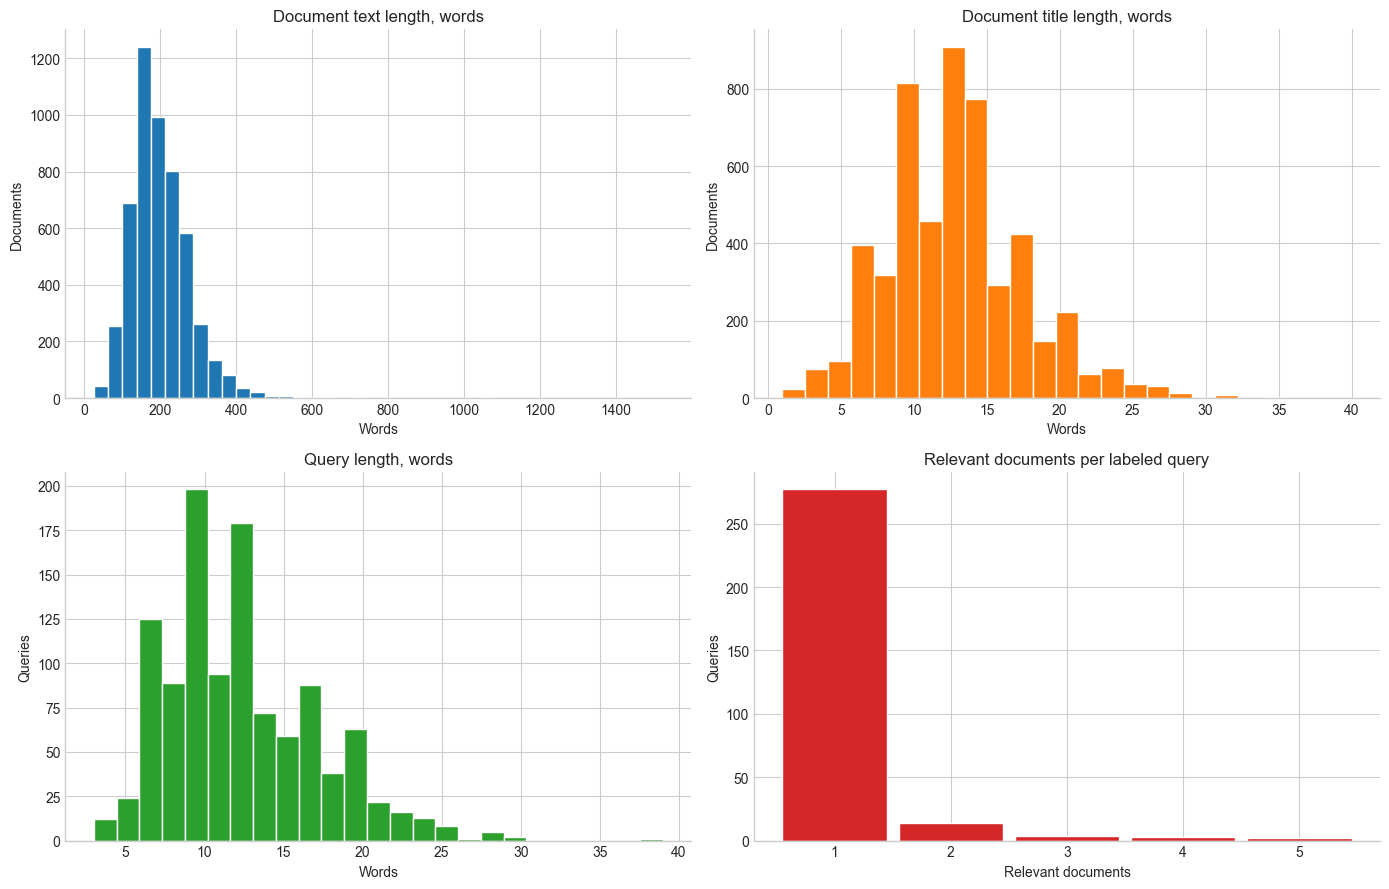

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(corpus["text_words"], bins=40, color="#1f77b4", edgecolor="white")
axes[0, 0].set_title("Document text length, words")
axes[0, 0].set_xlabel("Words")
axes[0, 0].set_ylabel("Documents")

axes[0, 1].hist(corpus["title_words"], bins=25, color="#ff7f0e", edgecolor="white")
axes[0, 1].set_title("Document title length, words")
axes[0, 1].set_xlabel("Words")
axes[0, 1].set_ylabel("Documents")

axes[1, 0].hist(queries["query_words"], bins=25, color="#2ca02c", edgecolor="white")
axes[1, 0].set_title("Query length, words")
axes[1, 0].set_xlabel("Words")
axes[1, 0].set_ylabel("Queries")

axes[1, 1].hist(qrels_per_query, bins=range(1, int(qrels_per_query.max()) + 2), align="left", color="#d62728", edgecolor="white", rwidth=0.9)
axes[1, 1].set_title("Relevant documents per labeled query")
axes[1, 1].set_xlabel("Relevant documents")
axes[1, 1].set_ylabel("Queries")

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [5]:
longest_docs = corpus.nlargest(10, "text_words")[["_id", "title", "text_words"]].reset_index(drop=True)
shortest_docs = corpus.nsmallest(10, "text_words")[["_id", "title", "text_words"]].reset_index(drop=True)

display(longest_docs)
display(shortest_docs)


,_id,title,text_words
0,10749308,Placebo-Controlled Trials and Active-Control Trials in the Evaluation of New Treatments. Part 1: Ethical and Scienti...,1524
1,26067999,Screening for Lung Cancer: U.S. Preventive Services Task Force Recommendation Statement,1511
2,86217760,The Self-Incompatibility Genes of Brassica: Expression and Use in Genetic Ablation of Floral Tissues,1066
3,27768226,Open Access Increases Citation Rate,1065
4,15521377,Keeping your senescent cells under control,1052
5,5114940,Pharmacological interventions for smoking cessation: an overview and network meta-analysis.,842
6,12207167,Adverse effects of excessive consumption of amino acids.,838
7,10374686,Developing primary palliative care.,793
8,6670101,Ribosome biogenesis: Achilles heel of cancer?,775
9,37248570,Malaria eradication back on the table.,729


,_id,title,text_words
0,33989422,On the origins of ultra-fine anaphase bridges.,26
1,80109277,The Bitterest Pills: The Troubling Story of Antipsychotic Drugs,36
2,70895396,The Endothelium: Modulator of Cardiovascular Function,39
3,29495185,New developments in the epidemiology of cancer prognosis: traditional and molecular predictors of treatment response...,42
4,74701974,The Women's Interagency HIV Study,44
5,38528892,The aurora B kinase promotes inner and outer kinetochore interactions in budding yeast.,47
6,81498132,Chromosome numbers in certain Indian species ofUtricularia L. (Lentibulariaceae),47
7,84244109,Innate immunity to a facultative intracellular bacterial pathogen.,47
8,10743131,Model-based Geostatistics,49
9,43427621,Psychological treatment of malignant vasovagal syncope due to bloodphobia.,50
